In [1]:
!pip install gensim

import gensim
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess
import numpy as np

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
    --------------------------------------- 0.5/24.4 MB 8.5 MB/s eta 0:00:03
   -- ------------------------------------- 1.6/24.4 MB 7.0 MB/s eta 0:00:04
   ----- ---------------------------------- 3.1/24.4 MB 6.2 MB/s eta 0:00:04
   ------- -------------------------------- 4.7/24.4 MB 6.6 MB/s eta 0:00:03
   ---------- ----------------------------- 6.3/24.4 MB 6.8 MB/s eta 0:00:03
   ------------ --------------------------- 7.6/24.4 MB 6.9 MB/s eta 0:00:03
   --------------- ------------------------ 9.2/24.4 MB 6.9 MB/s eta 0:00:03
   ----------------- ---------------------- 10.7/24.4 MB 6.9 MB/s eta 0:00:02
   ------------------- -------------------- 12.1/24.4 MB 7.0 MB/s eta 0:00:02
   ---------------------- ----------------- 13.6/24.4 MB 6.9 MB/s eta 0:00:02
   ------------------------ --------------- 15.2/24.4 MB 7.0 MB/s eta 0:00:02
   --------------------------- ------------ 16.8/24.4 MB 7.0 MB/s eta 0:00:02
 


[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Option A : Corpus anglais simple (Alice in Wonderland)
import urllib.request

url = "https://www.gutenberg.org/files/11/11-0.txt"  # Alice in Wonderland
response = urllib.request.urlopen(url)
text = response.read().decode('utf-8')

# Garder les 50000 premiers caractères (assez pour une démo)
text = text[:50000]
print(f"Taille du corpus : {len(text)} caractères")

Taille du corpus : 50000 caractères


In [3]:
# Tokenizer simple (gensim s'en charge)
sentences = []
for line in text.split('.'):
    tokens = simple_preprocess(line)
    if len(tokens) > 3:  # Ignorer les phrases trop courtes
        sentences.append(tokens)

print(f"Nombre de phrases : {len(sentences)}")
print(f"Exemple : {sentences[0]}")

Nombre de phrases : 242
Exemple : ['start', 'of', 'the', 'project', 'gutenberg', 'ebook', 'illustration', 'alice', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition']


In [8]:
# Supprime la cellule d'entraînement et remplace par ceci :

import gensim.downloader as api

# Télécharger un modèle Word2Vec pré-entraîné sur Google News (1.6 Go)
# Ou un plus petit : 'glove-twitter-25' (rapide)
print("Téléchargement du modèle pré-entraîné...")
model = api.load('glove-twitter-25')  # 25 dimensions, rapide

print(f"Vocabulaire : {len(model.key_to_index):,} mots")

Téléchargement du modèle pré-entraîné...
[==================================================] 100.0% 104.8/104.8MB downloaded
Vocabulaire : 1,193,514 mots


In [10]:
# Mots les plus proches
test_words = ['king', 'queen', 'cat', 'computer', 'time']

for word in test_words:
    print(f"\n🔤 Mots proches de '{word}' :")
    for similar_word, score in model.most_similar(word, topn=5):
        print(f"  {similar_word}: {score:.4f}")


🔤 Mots proches de 'king' :
  prince: 0.9337
  queen: 0.9202
  aka: 0.9177
  lady: 0.9163
  jack: 0.9147

🔤 Mots proches de 'queen' :
  princess: 0.9394
  lady: 0.9336
  prince: 0.9269
  king: 0.9202
  aka: 0.8977

🔤 Mots proches de 'cat' :
  dog: 0.9591
  monkey: 0.9204
  bear: 0.9143
  pet: 0.9108
  girl: 0.8881

🔤 Mots proches de 'computer' :
  camera: 0.9078
  cell: 0.8919
  server: 0.8745
  device: 0.8694
  wifi: 0.8631

🔤 Mots proches de 'time' :
  break: 0.9539
  way: 0.9423
  next: 0.9418
  take: 0.9327
  now: 0.9321


In [12]:
# Analogies
def analogy(model, word_a, word_b, word_c):
    try:
        result = model.most_similar(
            positive=[word_c, word_a],
            negative=[word_b],
            topn=3
        )
        print(f"\n🔮 {word_a} - {word_b} + {word_c} = ?")
        for word, score in result:
            print(f"  {word}: {score:.4f}")
    except KeyError as e:
        print(f"❌ Mot absent : {e}")

analogy(model, 'king', 'man', 'woman')
analogy(model, 'paris', 'france', 'italy')
analogy(model, 'walking', 'walk', 'swim')


🔮 king - man + woman = ?
  meets: 0.8842
  prince: 0.8322
  queen: 0.8257

🔮 paris - france + italy = ?
  brazil: 0.8409
  thailand: 0.7927
  milan: 0.7709

🔮 walking - walk + swim = ?
  swimming: 0.8787
  skating: 0.8658
  fireworks: 0.8622


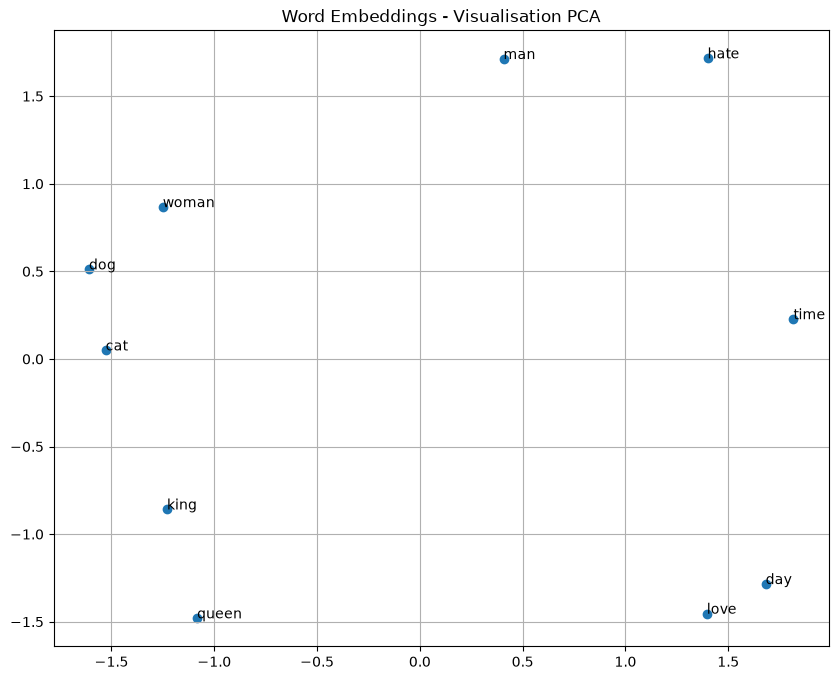

In [14]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Sélectionner quelques mots à visualiser
words_to_plot = ['king', 'queen', 'man', 'woman', 'cat', 'dog', 'love', 'hate', 'time', 'day']

# Récupérer les vecteurs
vectors = []
labels = []
for word in words_to_plot:
    if word in model:
        vectors.append(model[word])
        labels.append(word)

# Réduire à 2D avec PCA
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1])

for i, label in enumerate(labels):
    plt.annotate(label, (vectors_2d[i, 0], vectors_2d[i, 1]))

plt.title('Word Embeddings - Visualisation PCA')
plt.grid(True)
plt.show()

# 📋 RÉSUMÉ TP7 — Word Embeddings (Word2Vec)

---

## 🧠 POURQUOI CE TP ?

### Le problème qu'on résout

Jusqu'ici, on représentait les mots de façon stupide :

| Mot | Représentation |
|-----|---------------|
| `king` | 1 |
| `queen` | 2 |
| `cat` | 3 |

Problème : `king` (1) est aussi proche de `queen` (2) que de `cat` (3). Les nombres n'ont **aucun sens**.

### La solution : les word embeddings

Chaque mot devient un **vecteur de 100 nombres** (ou 25, 300...). Ces nombres sont appris pour que les mots qui apparaissent dans les **mêmes contextes** aient des vecteurs **proches**.

```
king   = [0.2, 0.5, -0.1, 0.8, ...]
queen  = [0.3, 0.4, -0.1, 0.9, ...]  ← très proche de king
cat    = [-0.5, 0.1, 0.7, -0.3, ...] ← très différent
```

---

## 🔮 LE SAVOIR CACHÉ

> **Un mot est défini par ses voisins.** Word2Vec n'apprend jamais la définition d'un mot. Il apprend juste à prédire les mots qui l'entourent. Le sens **émerge** comme sous-produit : deux mots qui apparaissent dans les mêmes contextes finissent avec des vecteurs proches.

**Conséquence magique :** Les relations entre mots deviennent des **directions dans l'espace**.

```
vecteur(king) - vecteur(man) + vecteur(woman) ≈ vecteur(queen)
         ↓
   La direction "royauté" reste, le genre change
```

---

## 👁️ EXEMPLE CONCRET

Dans des millions de phrases, on voit :

- `"The king ruled the kingdom"`
- `"The queen ruled the kingdom"`
- `"The king and queen arrived"`
- `"The man walked his dog"`
- `"The woman walked her dog"`

Le modèle remarque que `king` et `queen` apparaissent avec les mêmes mots (`ruled`, `kingdom`, `arrived`). Donc leurs vecteurs deviennent proches.

Mais `king` apparaît plus avec `man`, et `queen` avec `woman`. Donc la **différence** `king - man + woman` pointe vers `queen`.

---

## 💻 LE CODE LIGNE PAR LIGNE

### 1. Charger un modèle pré-entraîné

```python
import gensim.downloader as api

# Télécharge un modèle déjà entraîné sur des millions de tweets
# glove-twitter-25 = 25 dimensions, 1.2 million de mots
model = api.load('glove-twitter-25')
```

**Pourquoi un modèle pré-entraîné ?**
- Entraîner Word2Vec soi-même demande des **millions de phrases** et des **heures de calcul**
- Le modèle pré-entraîné a déjà appris sur 2 milliards de tweets
- On peut l'utiliser directement

### 2. Trouver les mots proches

```python
model.most_similar('king', topn=5)
```

**Ce que ça fait :** Calcule la similarité cosinus entre le vecteur de `king` et **tous les autres mots** du vocabulaire (1.2 million). Retourne les 5 plus proches.

```
king → prince (0.93), queen (0.92), lady (0.91)...
```

**Interprétation :** `prince` et `queen` sont proches de `king` car ils apparaissent dans des contextes similaires (royauté, pouvoir, château...).

### 3. Les analogies

```python
model.most_similar(positive=['woman', 'king'], negative=['man'])
```

**Ce que ça fait :**
1. Prend le vecteur de `king`
2. Soustrait le vecteur de `man` (enlève le genre masculin)
3. Ajoute le vecteur de `woman` (ajoute le genre féminin)
4. Cherche le vecteur le plus proche du résultat

```
king - man + woman = queen ✅
```

**Pourquoi ça marche ?** La direction `man → woman` encode le changement de genre. Cette direction est la même pour `king → queen`, `prince → princess`, `actor → actress`.

### 4. Visualisation PCA

```python
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)
```

**Ce que ça fait :** Les vrais vecteurs ont 25 dimensions (ou 100, 300). Impossible à visualiser. PCA réduit à 2 dimensions pour qu'on puisse les voir sur un graphique, tout en gardant au maximum les distances relatives.

---

## 📊 NOS RÉSULTATS

### Mots proches

| Mot | Voisins |
|-----|---------|
| `king` | prince, queen, lady, jack |
| `queen` | princess, lady, prince, king |
| `cat` | dog, monkey, bear, pet |
| `computer` | camera, cell, server, device |

✅ Les voisins ont du sens sémantique.

### Analogies

| Formule | Réponse | Juste ? |
|---------|---------|---------|
| `king - man + woman` | **queen** | ✅ |
| `paris - france + italy` | milan, brazil | ⚠️ (Rome aurait été parfait) |
| `walking - walk + swim` | **swimming** | ✅ |

---

## 🎓 CE QUE J'AI APPRIS

| Concept | Explication simple |
|---------|-------------------|
| **Word Embedding** | Vecteur de nombres qui représente le sens d'un mot |
| **Word2Vec** | Algorithme qui apprend ces vecteurs à partir du contexte |
| **Hypothèse distributionnelle** | "Un mot est défini par ses voisins" |
| **Similarité cosinus** | Mesure si 2 vecteurs pointent dans la même direction |
| **Analogies vectorielles** | Les relations entre mots deviennent des directions dans l'espace |
| **Modèle pré-entraîné** | Déjà entraîné sur des milliards de phrases, prêt à l'emploi |
| **PCA** | Réduit les dimensions pour visualiser les vecteurs |

---

## 🔄 COMPARAISON AVEC LES TP PRÉCÉDENTS

| TP | Représentation des mots | Le sens est capturé ? |
|----|------------------------|----------------------|
| TP2 (Naive Bayes) | Compteur d'occurrences | ❌ Juste des fréquences |
| TP3 (LogReg) | Poids par mot | ❌ Un poids, pas de relation |
| TP6 (TF-IDF) | Score de rareté | ❌ Juste des stats |
| **TP7 (Word2Vec)** | **Vecteur de 25 nombres** | ✅ Relations sémantiques ! |

---

## 🛠 CAS PRATIQUE : À quoi ça sert ?

```python
# 1. Trouver des synonymes pour enrichir un texte
model.most_similar('happy')
# → glad, excited, proud, pleased...

# 2. Corriger l'orthographe
model.most_similar('recieve')  # mot mal orthographié
# → receive, received, receives...

# 3. Recommandation de produits
# Si un client achète "laptop", quels produits suggérer ?
model.most_similar('laptop')
# → computer, desktop, pc, notebook...
```

---

## ⚠️ POURQUOI L'ENTRAÎNEMENT MAISON A ÉCHOUÉ

On a essayé d'entraîner Word2Vec sur 50 000 caractères d'Alice in Wonderland :

- **746 mots** de vocabulaire → beaucoup trop peu
- `king` et `queen` n'étaient même pas dans le texte
- Pour que Word2Vec fonctionne, il faut :
  - **Des millions de phrases**
  - **Des heures d'entraînement**
  - **Un vocabulaire de 50 000+ mots**

D'où l'utilisation du modèle pré-entraîné.